In [105]:
from FastBEMT.Propeller import Propeller
from FastBEMT.JobParameters import LowFidelityParameters
import pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'no-latex'])

with open("../Datasets/Propellers/10x7E.pkl", "rb") as f:
    blade_dict = pickle.load(f)

In [106]:
params = LowFidelityParameters(
    rpm=7000,
    a_inf=343,
    rho=1.225,
    mu=1.81e-5,
    n_blades=blade_dict['n_blades'],
    p_ref=2e-5,
    revolutions=2,
    num_obs_times_per_rev=50,
    device='cuda'
)

In [ ]:
nx, ny = 50, 25

In [138]:
x_range = np.linspace(-5.0, 5.0, nx)
y_range = np.linspace(0, 5.0, ny)
X, Y = np.meshgrid(x_range, y_range)
Z = np.zeros_like(X) 

r_observers = np.stack([X.flatten(), Y.flatten(), Z.flatten()], axis=1)

propeller = Propeller(
    propeller_geometry=blade_dict,
    params=params,
    dtype=torch.float32
)

propeller.run_bemt(v_inf=0.0)

In [ ]:
propeller.run_aeroacoustics(observer_positions=r_observers, keep_bpm_components=False)

[CUDA TIMING] TorchCompactAcousticSourceArray.__init__: 6.337 ms
[CUDA TIMING] BPM.__init__: 1.375 ms
[CUDA TIMING] get_observer_times (F1A): 10.994 ms
[CUDA TIMING] get_observer_times (BPM): 5.422 ms


In [ ]:
f_low = propeller.third_octave_freqs / (2 ** (1 / 6))
f_high = propeller.third_octave_freqs * (2 ** (1 / 6))
freqs = propeller.freq[:, 0]
mask = (propeller.freq[:, 0:1].T >= f_low.unsqueeze(1)) & \
       (propeller.freq[:, 0:1].T < f_high.unsqueeze(1))

# 4. Convert SPL to Power
p_raw = 10 ** (propeller.spl / 10)
p_band = torch.matmul(mask.float(), p_raw)
f1a_spl_3oct = 10 * torch.log10(p_band.clamp(min=1e-12))
f1a_spl_3oct[p_band == 0] = float('-inf')

In [ ]:
L_total = 10 * torch.log10(
    10 ** (f1a_spl_3oct / 10)
    + 10 ** (propeller.spl_total / 10)
)

In [ ]:
L_grid = L_total.reshape(L_total.shape[0], ny, nx)
blade_passing_freq = 1 / params.blade_passing_period

In [ ]:
OSPL_grid = 10 * torch.log10(torch.sum(10**(L_grid[propeller.third_octave_freqs >= 0.9*blade_passing_freq] / 10), axis=0)).cpu()

C:\Users\Davide Pusino\AppData\Local\Temp\ipykernel_21840\2699243237.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  vmin = np.floor(OSPL_grid.min() / 5) * 5
C:\Users\Davide Pusino\AppData\Local\Temp\ipykernel_21840\2699243237.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  vmax = np.ceil(OSPL_grid.max() / 5) * 5


C:\Users\Davide Pusino\AppData\Local\Temp\ipykernel_21840\2699243237.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  cbar = fig.colorbar(cf, ax=ax, ticks=np.arange(vmin, vmax + 5, 5))
C:\Users\Davide Pusino\AppData\Local\Temp\ipykernel_21840\2699243237.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  line_levels = np.arange(vmin, vmax + 5, 10)


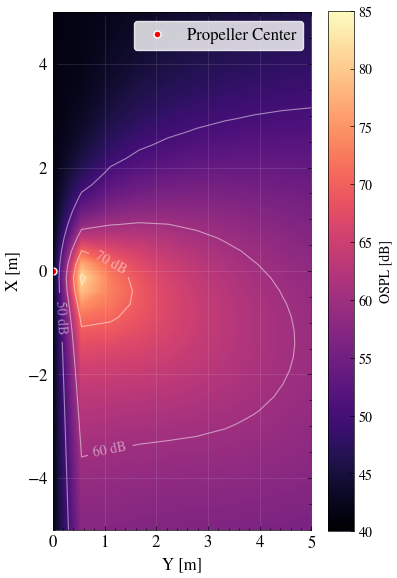

In [ ]:
fig, ax = plt.subplots(figsize=(4, 6))

vmin = np.floor(OSPL_grid.min() / 5) * 5
vmax = np.ceil(OSPL_grid.max() / 5) * 5
smooth_levels = np.linspace(vmin, vmax, 1000)
cf = ax.contourf(Y, X, OSPL_grid, levels=smooth_levels, cmap='magma')
cbar = fig.colorbar(cf, ax=ax, ticks=np.arange(vmin, vmax + 5, 5))
cbar.set_label('OSPL [dB]')

# 4. (Optional) Sync the contour lines with the new range
line_levels = np.arange(vmin, vmax + 5, 10)
contours = ax.contour(Y, X, OSPL_grid, levels=line_levels, colors='white', linewidths=0.8, alpha=0.5)
ax.clabel(contours, inline=True, fontsize=10, fmt='%1.0f dB')

ax.plot(0, 0, 'ro', markersize=5, label='Propeller Center', markeredgecolor='white')

ax.set_xlabel('Y [m]', fontsize=12)
ax.set_ylabel('X [m]', fontsize=12)

ax.set_aspect('equal')
ax.grid(True, alpha=0.15, color='white')
plt.legend(fontsize=12, frameon=True, edgecolor='white')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
from shapely.geometry import Polygon, box

target_level = 60.0
weight_below = 2.0  # Weight for the area where X < 0
weight_above = 1.0  # Weight for the area where X >= 0

specific_contour = ax.contour(Y, X, OSPL_grid, levels=[target_level])
bottom_half_box = box(-5.0, -5.0, 5.0, 0.0) 
top_half_box = box(-5.0, 0.0, 5.0, 5.0)

area_above = 0.0
area_below = 0.0

for path in specific_contour.get_paths():
    vertices = path.vertices
    if len(vertices) > 3:
        poly = Polygon(vertices)
        
        poly_below = poly.intersection(bottom_half_box)
        poly_above = poly.intersection(top_half_box)
        
        area_below += poly_below.area
        area_above += poly_above.area

weighted_area = (area_below * weight_below) + (area_above * weight_above)
total_raw_area = area_below + area_above

print(f"--- Analysis for {target_level} dB ---")
print(f"Raw Area Below (X < 0): {area_below:.4f} m^2")
print(f"Raw Area Above (X >= 0): {area_above:.4f} m^2")
print(f"Weighted Total Area (Weight={weight_below}x): {weighted_area:.4f} m^2")

--- Analysis for 60.0 dB ---
Raw Area Below (X < 0): 12.9396 m^2


Raw Area Above (X >= 0): 2.7068 m^2
Weighted Total Area (Weight=2.0x): 28.5859 m^2
